# Medical Abstract PIO Classification and Agreement Calibration

This notebook fine-tunes PubMedBERT to detect **Population (P), Intervention (I),
and Outcome (O) presence in individual sentences**. Each label is independent:
a sentence can receive multiple labels or none. It also evaluates whether post-hoc
calibration improves prediction of crowd-annotator agreement.

## Recorded results

The supplied run completed in Colab with **Python 3.12.13 and an A100 GPU**.
The selected epoch-2 checkpoint achieved validation micro-F1 **0.8087**.
On 2,075 test sentences from 191 documents, expert-majority F1 was **0.8565 (P),
0.8539 (I), and 0.8578 (O)**. Both calibration methods reduced agreement MSE;
all six document-bootstrap improvement intervals were above zero.

The outputs below come from that completed run. Setup, documentation, export, and
demo-loading code were subsequently cleaned; this edited notebook has not been
rerun end to end. The data partition and numerical training/calibration settings
for the recorded A100 run are retained.

The author subsequently tested the quick demo in a restarted Colab session with
only the backup ZIP uploaded. All four displayed labels and scores matched the
original run to four decimal places. Package installation still reported conflicts
with Colab's preinstalled packages; this successful inference check does not
establish a globally consistent environment or a fresh full training rerun.

## How to use this notebook

- **Quick prediction demo:** run the installation cell once, restart the session,
  then skip to **Example predictions on new text** at the bottom. Upload the
  author-exported `picos_model_and_results.zip` to the working directory first,
  or extract its `selected_base_model` folder into `picos_work/artifacts/`.
  The demo loads the saved model without training or dataset downloads. The ZIP
  is supplied separately; public checkpoint hosting is not yet configured.
- **Full training and evaluation:** in Colab choose Runtime → Change runtime type
  → Runtime Version **2026.07**, and A100 GPU to match the recorded environment.
  Run the installation cell once, restart the session, then run from the imports
  cell downward. Skip the installation cell after restarting. Downloaded model
  and dataset revisions are pinned; seeds do not guarantee identical results
  across hardware and software environments.

## Evaluation scope

Training, validation, calibration, and test partitions are disjoint by document.
Validation micro-F1 selects the classifier; calibration documents fit the mappings.
Test data is excluded from this run's model fitting, checkpoint selection, and
calibrator fitting. The test corpus was analyzed in earlier project work, so it is
not a previously unseen external benchmark. This protocol is not claimed to have
been formally preregistered. Freeze future choices before a new final evaluation.

This is sentence classification, not phrase/span extraction or a complete PICOS
system. No independent Comparison or Study Design classifier is implemented here.
Crowd disagreement and expert-label errors are separate quantities; calibrated
agreement scores are not probabilities that the classifier is correct.

In [ ]:
# Environment setup: run once, then restart the session before importing packages.
# Recorded run: Colab runtime 2026.07, Python 3.12.13, A100 GPU.
import sys
if sys.version_info[:2] not in {(3, 11), (3, 12)}:
    raise RuntimeError(
        "Use Python 3.11 or 3.12. In Colab select runtime version 2026.07."
    )

%pip install -q "transformers==4.49.0" "datasets==3.2.0" "accelerate==1.2.1" "scikit-learn==1.6.1" "numpy==1.26.4" "pandas==2.2.3" "matplotlib==3.10.0" "torch==2.6.0" "joblib==1.5.3"

# Colab's preinstalled vision/audio extensions may target a newer PyTorch.
# Neither extension is needed for this text-only notebook.
%pip uninstall -y torchvision torchaudio
print("Setup complete. Restart the session, then skip this cell and continue.")

In [1]:
from __future__ import annotations

import json
import os
import random
import subprocess
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from datasets import Dataset
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, precision_recall_fscore_support
os.environ["USE_TF"] = "0"
os.environ["USE_FLAX"] = "0"
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
    set_seed,
)

SEED = 20260806
MODEL_NAME = "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext"
MODEL_REVISION = "e1354b7a3a09615f6aba48dfad4b7a613eef7062"
EBM_REPO = "https://github.com/bepnye/EBM-NLP.git"
EBM_REVISION = "43a4a1ea3f0a21cfb8820c040b843dfaf66192d0"
MAX_LENGTH = 128
WORKDIR = Path("picos_work").resolve()
DATA_ROOT = WORKDIR / "EBM-NLP" / "ebm_nlp_1_00"
ARTIFACTS = WORKDIR / "artifacts"
ARTIFACTS.mkdir(parents=True, exist_ok=True)

# PYTHONHASHSEED must be set before kernel startup to affect hash randomization.
random.seed(SEED)
np.random.seed(SEED)
set_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print({
    "seed": SEED,
    "torch": torch.__version__,
    "cuda": torch.cuda.is_available(),
    "model_revision": MODEL_REVISION,
    "dataset_revision": EBM_REVISION,
})

{'seed': 20260806, 'torch': '2.6.0+cu124', 'cuda': True, 'model_revision': 'e1354b7a3a09615f6aba48dfad4b7a613eef7062', 'dataset_revision': '43a4a1ea3f0a21cfb8820c040b843dfaf66192d0'}


## Data provenance and document partitions

Source: [EBM-NLP 1.00](https://github.com/bepnye/EBM-NLP), pinned to the revision
specified below. Aggregated token annotations define binary training labels.
Individual crowd annotations define separate sentence-level agreement targets.

Training learns the classifier, validation selects its checkpoint, calibration fits
the agreement mappings, and test documents measure final performance. No threshold
is tuned on the test set. The partition manifest stores exact document IDs.

In [2]:
def run(cmd: list[str], cwd: Path | None = None) -> None:
    subprocess.run(cmd, cwd=cwd, check=True)


def ensure_ebm_nlp() -> Path:
    repo = WORKDIR / "EBM-NLP"
    if not repo.exists():
        WORKDIR.mkdir(parents=True, exist_ok=True)
        run(["git", "clone", EBM_REPO, str(repo)])
    run(["git", "fetch", "--tags", "--force", "origin"], cwd=repo)
    run(["git", "checkout", "--detach", EBM_REVISION], cwd=repo)
    archive = repo / "ebm_nlp_1_00.tar.gz"
    if not DATA_ROOT.exists():
        run(["tar", "-xzf", str(archive), "-C", str(repo)])
    assert DATA_ROOT.exists(), f"Expected extracted data at {DATA_ROOT}"
    revision = subprocess.check_output(["git", "rev-parse", "HEAD"], cwd=repo, text=True).strip()
    assert revision == EBM_REVISION
    return DATA_ROOT


DATA_ROOT = ensure_ebm_nlp()
print(DATA_ROOT)

/content/picos_work/EBM-NLP/ebm_nlp_1_00


In [3]:
CATEGORIES = {"P": "participants", "I": "interventions", "O": "outcomes"}


def load_ann(path: Path) -> list[int]:
    values = path.read_text().strip()
    return [int(value) for value in values.split(",")] if values else []


def sentence_spans(tokens: list[str]) -> list[tuple[int, int]]:
    # Preserve original token indices. Splitting on standalone periods is heuristic;
    # pre-tokenisation does not guarantee correct sentence boundaries.
    spans, start = [], 0
    for idx, token in enumerate(tokens):
        if token == ".":
            spans.append((start, idx + 1))
            start = idx + 1
    if start < len(tokens):
        spans.append((start, len(tokens)))
    return spans


def aggregated_doc_ids(split: str) -> set[str]:
    folder = DATA_ROOT / "annotations" / "aggregated" / "starting_spans" / "participants" / split
    if split == "test":
        folder = folder / "gold"
    return {path.name.removesuffix("_AGGREGATED.ann") for path in folder.glob("*_AGGREGATED.ann")}


def individual_files(split: str) -> dict[str, dict[str, list[Path]]]:
    result = {}
    for short, category in CATEGORIES.items():
        folder = DATA_ROOT / "annotations" / "individual" / "starting_spans" / category / split
        by_doc: dict[str, list[Path]] = defaultdict(list)
        for path in folder.glob("*.ann"):
            by_doc[path.name.split("_")[0]].append(path)
        result[short] = by_doc
    return result


def build_aggregated_rows(doc_ids: set[str], split: str) -> list[dict]:
    rows = []
    for doc_id in sorted(doc_ids):
        token_path = DATA_ROOT / "documents" / f"{doc_id}.tokens"
        tokens = token_path.read_text().split()
        labels = {}
        for short, category in CATEGORIES.items():
            folder = DATA_ROOT / "annotations" / "aggregated" / "starting_spans" / category / split
            if split == "test":
                folder = folder / "gold"
            labels[short] = load_ann(folder / f"{doc_id}_AGGREGATED.ann")
            assert len(labels[short]) == len(tokens), (doc_id, short)
        for start, end in sentence_spans(tokens):
            if end - start < 3:
                continue
            row = {"doc_id": doc_id, "start": start, "end": end, "text": " ".join(tokens[start:end])}
            row.update({short: int(any(labels[short][start:end])) for short in CATEGORIES})
            rows.append(row)
    return rows


def build_crowd_rows(doc_ids: set[str], split: str) -> list[dict]:
    files = individual_files(split)
    rows = []
    for doc_id in sorted(doc_ids):
        tokens = (DATA_ROOT / "documents" / f"{doc_id}.tokens").read_text().split()
        votes = {}
        for short in CATEGORIES:
            annotations = [load_ann(path) for path in files[short][doc_id]]
            annotations = [ann for ann in annotations if len(ann) == len(tokens)]
            if len(annotations) < 3:
                votes = {}
                break
            votes[short] = annotations
        if not votes:
            continue
        for start, end in sentence_spans(tokens):
            if end - start < 3:
                continue
            row = {"doc_id": doc_id, "start": start, "end": end, "text": " ".join(tokens[start:end])}
            for short, annotations in votes.items():
                per_annotator = np.array([int(any(ann[start:end])) for ann in annotations])
                row[f"{short}_human"] = per_annotator.mean()
                row[f"{short}_n"] = len(per_annotator)
                row[f"{short}_votes"] = int(per_annotator.sum())
            rows.append(row)
    return rows


def document_split(doc_ids: set[str], calibration_fraction: float = 0.15):
    docs = np.array(sorted(doc_ids))
    rng = np.random.default_rng(SEED)
    rng.shuffle(docs)
    cut = round(len(docs) * calibration_fraction)
    return set(docs[cut:]), set(docs[:cut])

In [4]:
# Reserve 15% of eligible training documents for calibration.
# Split the remaining training documents into base training and validation.
train_docs = aggregated_doc_ids("train")
train_crowd = individual_files("train")

calibration_candidates = train_docs & set.intersection(
    *(set(train_crowd[short]) for short in CATEGORIES)
)
assert len(calibration_candidates) >= 2, "Too few calibration candidates."

eligible_docs = np.array(sorted(calibration_candidates))
rng = np.random.default_rng(SEED)
rng.shuffle(eligible_docs)

n_calibration = min(
    len(eligible_docs) - 1,
    max(1, round(len(eligible_docs) * 0.15)),
)
calibration_docs = set(eligible_docs[:n_calibration])

remaining_docs = train_docs - calibration_docs
assert len(remaining_docs) >= 2, "Too few documents for training/validation."

base_train_docs, base_validation_docs = document_split(
    remaining_docs, calibration_fraction=0.12
)

test_crowd = individual_files("test/crowd")
locked_test_docs = set.intersection(
    *(set(test_crowd[short]) for short in CATEGORIES)
)

partitions = {
    "base_train": base_train_docs,
    "base_validation": base_validation_docs,
    "calibration": calibration_docs,
    "locked_test": locked_test_docs,
}

for name, docs in partitions.items():
    assert docs, f"Empty document partition: {name}"

names = list(partitions)
for index, name in enumerate(names):
    for other in names[index + 1:]:
        assert partitions[name].isdisjoint(partitions[other]), (
            f"Document overlap: {name} / {other}"
        )

assert train_docs.isdisjoint(locked_test_docs)

base_train_rows = build_aggregated_rows(base_train_docs, "train")
base_validation_rows = build_aggregated_rows(base_validation_docs, "train")
calibration_rows = build_crowd_rows(calibration_docs, "train")
locked_test_rows = build_crowd_rows(locked_test_docs, "test/crowd")

row_partitions = {
    "base_train": base_train_rows,
    "base_validation": base_validation_rows,
    "calibration": calibration_rows,
    "locked_test": locked_test_rows,
}

for name, rows in row_partitions.items():
    assert rows, f"No usable sentences in {name}."

# Check that training/validation contain positives and negatives for each label.
for name in ["base_train", "base_validation"]:
    for short in CATEGORIES:
        values = {row[short] for row in row_partitions[name]}
        assert values == {0, 1}, f"{name}: insufficient class coverage for {short}"

# Logistic calibration needs both positive and negative annotator votes.
for short in CATEGORIES:
    positives = sum(row[f"{short}_votes"] for row in calibration_rows)
    totals = sum(row[f"{short}_n"] for row in calibration_rows)
    assert 0 < positives < totals, f"Calibration lacks vote diversity for {short}"

split_manifest = {
    "seed": SEED,
    "calibration_fraction": 0.15,
    "validation_fraction_of_remaining": 0.12,
    "partitions": {
        name: {
            "assigned_document_ids": sorted(partitions[name]),
            "retained_document_ids": sorted({row["doc_id"] for row in rows}),
        }
        for name, rows in row_partitions.items()
    },
}
(ARTIFACTS / "document_splits.json").write_text(
    json.dumps(split_manifest, indent=2) + "\n"
)

display(pd.DataFrame([
    {
        "partition": name,
        "assigned documents": len(partitions[name]),
        "retained documents": len({row["doc_id"] for row in rows}),
        "sentences": len(rows),
    }
    for name, rows in row_partitions.items()
]))

,partition,assigned documents,retained documents,sentences
0,base_train,3592,3592,38147
1,base_validation,490,490,5344
2,calibration,720,720,7670
3,locked_test,191,191,2075


## Base PIO model

The classifier is selected only by validation micro-F1 on documents outside base-model
training. It learns aggregated training labels. The later calibration target is a
different quantity: the fraction of individual crowd annotators marking any token in a
sentence.

In [5]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, revision=MODEL_REVISION)


def to_dataset(rows: list[dict], label_columns: list[str]) -> Dataset:
    frame = pd.DataFrame(rows)[["text", *label_columns]].copy()
    frame["labels"] = frame[label_columns].astype(float).values.tolist()
    return Dataset.from_pandas(frame[["text", "labels"]], preserve_index=False)


def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)


train_ds = to_dataset(base_train_rows, ["P", "I", "O"]).map(tokenize, batched=True, remove_columns=["text"])
validation_ds = to_dataset(base_validation_rows, ["P", "I", "O"]).map(tokenize, batched=True, remove_columns=["text"])
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


def metrics(eval_pred):
    logits, labels = eval_pred
    probs = 1 / (1 + np.exp(-logits))
    pred = (probs >= 0.5).astype(int)
    return {"micro_f1": f1_score(labels, pred, average="micro", zero_division=0)}


model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    revision=MODEL_REVISION,
    num_labels=3,
    problem_type="multi_label_classification",
    id2label={0: "P", 1: "I", 2: "O"},
    label2id={"P": 0, "I": 1, "O": 2},
)
args = TrainingArguments(
    output_dir=str(ARTIFACTS / "base_model"),
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    num_train_epochs=4,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="micro_f1",
    greater_is_better=True,
    save_total_limit=2,
    seed=SEED,
    data_seed=SEED,
    report_to="none",
    bf16=torch.cuda.is_available() and torch.cuda.is_bf16_supported(),
)
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=validation_ds,
    data_collator=data_collator,
    compute_metrics=metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)
trainer.train()
trainer.save_model(ARTIFACTS / "selected_base_model")
tokenizer.save_pretrained(ARTIFACTS / "selected_base_model")
print("Selected checkpoint:", trainer.state.best_model_checkpoint)
print(trainer.evaluate())

Epoch,Training Loss,Validation Loss,Micro F1
1,0.382400,0.351213,0.805579
2,0.318900,0.365249,0.808655
3,0.267500,0.390962,0.808196
4,0.226800,0.422038,0.803042


Selected checkpoint: /content/picos_work/artifacts/base_model/checkpoint-4770


{'eval_loss': 0.3652491867542267, 'eval_micro_f1': 0.8086553770444348, 'eval_runtime': 1.9297, 'eval_samples_per_second': 2769.31, 'eval_steps_per_second': 43.53, 'epoch': 4.0}


In [6]:
def predict_proba(rows: list[dict], model_dir: Path) -> np.ndarray:
    inference_model = AutoModelForSequenceClassification.from_pretrained(model_dir).eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    inference_model.to(device)
    result = []
    for start in range(0, len(rows), 64):
        texts = [row["text"] for row in rows[start : start + 64]]
        batch = tokenizer(texts, padding=True, truncation=True, max_length=MAX_LENGTH, return_tensors="pt")
        batch = {name: values.to(device) for name, values in batch.items()}
        with torch.inference_mode():
            result.append(torch.sigmoid(inference_model(**batch).logits).cpu().numpy())
    return np.vstack(result)


calibration_probs = predict_proba(calibration_rows, ARTIFACTS / "selected_base_model")
test_probs = predict_proba(locked_test_rows, ARTIFACTS / "selected_base_model")
np.save(ARTIFACTS / "calibration_raw_probs.npy", calibration_probs)
np.save(ARTIFACTS / "locked_test_raw_probs.npy", test_probs)

## Post-hoc agreement calibration

Mappings fit solely on the document-disjoint calibration partition. We compare
raw sigmoid scores, logistic calibration on **probability inputs**, and isotonic
regression. The logistic variant is not conventional Platt scaling on logits;
the historical internal key `platt` is retained for artifact compatibility.

Fitting weights each sentence by its number of annotators. Test MSE, MAE, and
10-bin agreement ECE weight sentences equally. These metrics target the fraction
of annotators marking any token, not expert-label correctness. A high sentence
agreement score can coexist with disagreement about the exact phrase boundaries.

In [7]:
def fit_platt(probabilities: np.ndarray, votes: np.ndarray, totals: np.ndarray) -> LogisticRegression:
    # Expand binomial vote counts into individual Bernoulli observations. This makes
    # logistic calibration target the probability that a randomly selected annotator marks it.
    x, y = [], []
    for p, positive, total in zip(probabilities, votes, totals):
        x.extend([p] * int(total))
        y.extend([1] * int(positive) + [0] * int(total - positive))
    return LogisticRegression(random_state=SEED, C=1e6, solver="lbfgs").fit(np.asarray(x).reshape(-1, 1), y)


calibrators = {}
for column_index, short in enumerate(["P", "I", "O"]):
    human = np.asarray([row[f"{short}_human"] for row in calibration_rows])
    votes = np.asarray([row[f"{short}_votes"] for row in calibration_rows])
    totals = np.asarray([row[f"{short}_n"] for row in calibration_rows])
    isotonic = IsotonicRegression(out_of_bounds="clip", y_min=0.0, y_max=1.0)
    isotonic.fit(calibration_probs[:, column_index], human, sample_weight=totals)
    platt = fit_platt(calibration_probs[:, column_index], votes, totals)
    calibrators[short] = {"isotonic": isotonic, "platt": platt}


def calibrated_predictions(raw: np.ndarray, method: str) -> np.ndarray:
    result = np.empty_like(raw)
    for index, short in enumerate(["P", "I", "O"]):
        model = calibrators[short][method]
        if method == "platt":
            result[:, index] = model.predict_proba(raw[:, [index]])[:, 1]
        else:
            result[:, index] = model.predict(raw[:, index])
    return result


test_platt = calibrated_predictions(test_probs, "platt")
test_isotonic = calibrated_predictions(test_probs, "isotonic")

,element,method,Agreement MSE,MAE,ECE (10 bins)
0,P,Raw,0.0608,0.1624,0.1344
1,P,Logistic (probability input),0.0204,0.1012,0.0341
2,P,Isotonic,0.0175,0.0918,0.0195
3,I,Raw,0.0730,0.2008,0.1759
4,I,Logistic (probability input),0.0215,0.1140,0.0577
5,I,Isotonic,0.0201,0.1087,0.0521
6,O,Raw,0.1003,0.2480,0.2254
7,O,Logistic (probability input),0.0236,0.1189,0.0518
8,O,Isotonic,0.0227,0.1149,0.0404


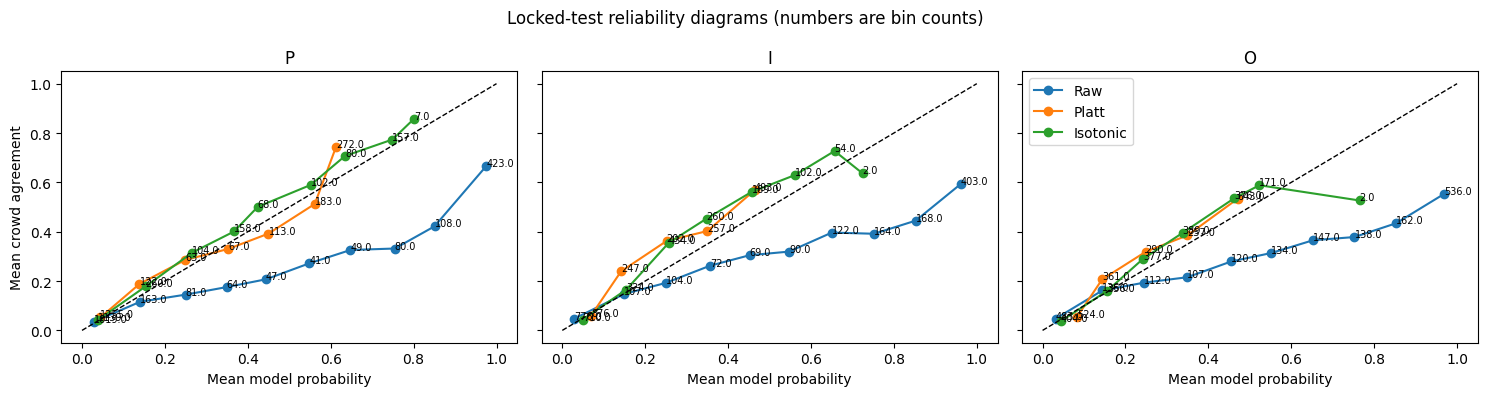

In [8]:
def ece(probabilities: np.ndarray, targets: np.ndarray, bins: int = 10) -> float:
    edges = np.linspace(0, 1, bins + 1)
    score = 0.0
    for index, (left, right) in enumerate(zip(edges[:-1], edges[1:])):
        mask = (probabilities >= left) & ((probabilities <= right) if index == bins - 1 else (probabilities < right))
        if mask.any():
            score += mask.mean() * abs(probabilities[mask].mean() - targets[mask].mean())
    return float(score)


def reliability_frame(probabilities: np.ndarray, targets: np.ndarray, bins: int = 10) -> pd.DataFrame:
    edges = np.linspace(0, 1, bins + 1)
    rows = []
    for index, (left, right) in enumerate(zip(edges[:-1], edges[1:])):
        mask = (probabilities >= left) & ((probabilities <= right) if index == bins - 1 else (probabilities < right))
        if mask.any():
            rows.append({"left": left, "right": right, "n": int(mask.sum()),
                         "mean_probability": probabilities[mask].mean(), "mean_human": targets[mask].mean()})
    return pd.DataFrame(rows)


human_test = np.asarray([[row[f"{short}_human"] for short in ["P", "I", "O"]] for row in locked_test_rows])
methods = {"Raw": test_probs, "Logistic (probability input)": test_platt, "Isotonic": test_isotonic}
report = []
for class_index, short in enumerate(["P", "I", "O"]):
    for method, values in methods.items():
        probability = values[:, class_index]
        target = human_test[:, class_index]
        report.append({"element": short, "method": method,
                       "Agreement MSE": np.mean((probability - target) ** 2),
                       "MAE": np.mean(abs(probability - target)),
                       "ECE (10 bins)": ece(probability, target)})
metrics_df = pd.DataFrame(report)
display(metrics_df.round(4))

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)
for class_index, (short, ax) in enumerate(zip(["P", "I", "O"], axes)):
    for method, values in methods.items():
        frame = reliability_frame(values[:, class_index], human_test[:, class_index])
        ax.plot(frame["mean_probability"], frame["mean_human"], marker="o", label=method)
        for _, item in frame.iterrows():
            ax.annotate(str(item["n"]), (item["mean_probability"], item["mean_human"]), fontsize=7)
    ax.plot([0, 1], [0, 1], "k--", linewidth=1)
    ax.set_title(short)
    ax.set_xlabel("Mean model probability")
axes[0].set_ylabel("Mean crowd agreement")
axes[-1].legend()
plt.suptitle("Held-out test reliability diagrams (numbers are bin counts)")
plt.tight_layout()
fig.savefig(ARTIFACTS / "agreement_reliability.png", dpi=160, bbox_inches="tight")
plt.show()

## Sentence classification against expert labels

The raw classifier's fixed **0.5** decision threshold is evaluated against majority
votes over individual expert sentence-presence labels. Ties are negative. These
targets differ from both crowd agreement fractions and token-aggregated labels.
No threshold is tuned on test documents. This table reports classification,
not span extraction or the accuracy of calibrated agreement scores.

In [9]:
def build_expert_gold_rows(doc_ids: set[str]) -> list[dict]:
    files = individual_files("test/gold")
    rows = []

    for doc_id in sorted(doc_ids):
        tokens = (DATA_ROOT / "documents" / f"{doc_id}.tokens").read_text().split()
        labels = {}

        for short in CATEGORIES:
            annotations = [
                load_ann(path)
                for path in files[short].get(doc_id, [])
            ]
            annotations = [
                ann for ann in annotations if len(ann) == len(tokens)
            ]
            if not annotations:
                labels = {}
                break
            labels[short] = annotations

        if not labels:
            continue

        for start, end in sentence_spans(tokens):
            if end - start < 3:
                continue

            row = {"doc_id": doc_id, "start": start, "end": end}
            for short, annotations in labels.items():
                per_annotator = [
                    int(any(annotation[start:end]))
                    for annotation in annotations
                ]
                # Majority vote over sentence-presence labels; ties are negative.
                row[f"{short}_gold"] = int(
                    sum(per_annotator) > len(per_annotator) / 2
                )
            rows.append(row)

    return rows


gold_rows = build_expert_gold_rows(locked_test_docs)
gold_by_key = {
    (row["doc_id"], row["start"], row["end"]): row
    for row in gold_rows
}
assert len(gold_by_key) == len(gold_rows), "Duplicate expert sentence keys."

alignment = [
    (index, gold_by_key[(row["doc_id"], row["start"], row["end"])])
    for index, row in enumerate(locked_test_rows)
    if (row["doc_id"], row["start"], row["end"]) in gold_by_key
]
assert len(alignment) == len(locked_test_rows), (
    "Investigate incomplete test/gold alignment."
)

indices = np.array([index for index, _ in alignment], dtype=int)
gold = np.array([
    [row[f"{short}_gold"] for short in ["P", "I", "O"]]
    for _, row in alignment
])

binary_report = []
for class_index, short in enumerate(["P", "I", "O"]):
    predictions = (test_probs[indices, class_index] >= 0.5).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(
        gold[:, class_index],
        predictions,
        average="binary",
        zero_division=0,
    )
    binary_report.append({
        "element": short,
        "precision": precision,
        "recall": recall,
        "F1": f1,
        "positive support": int(gold[:, class_index].sum()),
    })

display(pd.DataFrame(binary_report).round(4))

,element,precision,recall,F1,positive support
0,P,0.8046,0.9156,0.8565,616
1,I,0.9166,0.7993,0.8539,1086
2,O,0.9320,0.7947,0.8578,1310


In [10]:
def document_bootstrap_delta(
    raw: np.ndarray,
    calibrated: np.ndarray,
    human: np.ndarray,
    rows: list[dict],
    draws: int = 2000,
) -> pd.DataFrame:
    document_ids = np.asarray([row["doc_id"] for row in rows])
    unique_docs = np.unique(document_ids)
    assert len(unique_docs) >= 2, "Bootstrap requires at least two documents."
    assert raw.shape == calibrated.shape == human.shape == (len(rows), 3)

    indices_by_doc = {
        doc_id: np.flatnonzero(document_ids == doc_id)
        for doc_id in unique_docs
    }

    # Positive differences mean calibration reduces agreement MSE.
    sentence_deltas = (raw - human) ** 2 - (calibrated - human) ** 2
    observed_delta = sentence_deltas.mean(axis=0)

    rng = np.random.default_rng(SEED)
    bootstrap_deltas = np.empty((draws, 3))
    for draw in range(draws):
        sampled_docs = rng.choice(
            unique_docs, size=len(unique_docs), replace=True
        )
        indices = np.concatenate([
            indices_by_doc[doc_id] for doc_id in sampled_docs
        ])
        bootstrap_deltas[draw] = sentence_deltas[indices].mean(axis=0)

    records = []
    for class_index, short in enumerate(["P", "I", "O"]):
        low, high = np.quantile(
            bootstrap_deltas[:, class_index], [0.025, 0.975]
        )
        interpretation = (
            "Evidence of improvement" if low > 0
            else "Evidence of worsening" if high < 0
            else "Inconclusive"
        )
        records.append({
            "element": short,
            "MSE improvement": observed_delta[class_index],
            "95% CI low": low,
            "95% CI high": high,
            "interpretation": interpretation,
        })

    return pd.DataFrame(records)


bootstrap_reports = []
for method, probabilities in [
    ("Logistic (probability input)", test_platt),
    ("Isotonic", test_isotonic),
]:
    result = document_bootstrap_delta(
        test_probs, probabilities, human_test, locked_test_rows
    )
    result.insert(0, "method", method)
    bootstrap_reports.append(result)

bootstrap_df = pd.concat(bootstrap_reports, ignore_index=True)
display(bootstrap_df.round(4))

print(
    "Positive MSE improvement means lower error after calibration. "
    "An interval crossing zero is inconclusive; retain and report that result."
)

,method,element,MSE improvement,95% CI low,95% CI high,interpretation
0,Logistic (probability input),P,0.0404,0.0347,0.0467,Evidence of improvement
1,Logistic (probability input),I,0.0514,0.0445,0.0589,Evidence of improvement
2,Logistic (probability input),O,0.0768,0.0671,0.0863,Evidence of improvement
3,Isotonic,P,0.0433,0.0373,0.0498,Evidence of improvement
4,Isotonic,I,0.0528,0.0459,0.0602,Evidence of improvement
5,Isotonic,O,0.0777,0.0680,0.0872,Evidence of improvement


Positive MSE improvement means lower error after calibration. An interval crossing zero is inconclusive; retain and report that result.


## Interpretation and limitations

The recorded test results support lower sentence-level **agreement MSE** after
both calibration methods, with positive document-bootstrap improvement intervals
for every element. These intervals compare each method against raw scores; they
do not establish that isotonic is significantly better than logistic calibration.
Bootstrap intervals condition on this trained model and these fitted calibrators;
they do not include uncertainty from repeating training or calibration fitting.

Expert classification F1 is reported separately. Reduced agreement MSE does not
establish improved classification F1 or reliable detection of ambiguous text.
The exploratory ambiguity-flag experiment is excluded from this public notebook.

Limitations include heuristic sentence boundaries, truncation at 128 tokenizer
tokens, annotation-process dependence, and absent external labeled validation.
Synthetic predictions demonstrate the interface, not generalization accuracy.
No clinical usefulness, systematic-review eligibility performance, automatic
deferral reliability, or exact phrase extraction is established by this run.

In [11]:
# Write machine-readable, versioned artifacts for auditing and later external validation.
pd.DataFrame(locked_test_rows).assign(
    P_raw=test_probs[:, 0], I_raw=test_probs[:, 1], O_raw=test_probs[:, 2],
    P_isotonic=test_isotonic[:, 0], I_isotonic=test_isotonic[:, 1], O_isotonic=test_isotonic[:, 2],
).to_csv(ARTIFACTS / "locked_test_predictions.csv", index=False)
metrics_df.to_csv(ARTIFACTS / "locked_test_calibration_metrics.csv", index=False)
pd.DataFrame(binary_report).to_csv(ARTIFACTS / "locked_test_expert_binary_metrics.csv", index=False)
bootstrap_df.to_csv(ARTIFACTS / "locked_test_bootstrap_mse_delta.csv", index=False)

protocol = {
    "task": "sentence-level PIO presence classification; post-hoc crowd-agreement calibration",
    "model": {"name": MODEL_NAME, "revision": MODEL_REVISION},
    "dataset": {"repository": EBM_REPO, "revision": EBM_REVISION},
    "seed": SEED,
    "max_length": MAX_LENGTH,
    "test_set": "EBM-NLP individual test/crowd; untouched during base-model training and calibration fitting",
    "caveat": "External target-corpus annotations are required before deployment claims.",
}
(ARTIFACTS / "protocol.json").write_text(json.dumps(protocol, indent=2) + "\n")
print(f"Artifacts written to {ARTIFACTS}")

Artifacts written to /content/picos_work/artifacts


In [14]:
import sys
import zipfile
import joblib
from importlib.metadata import version

# Save the selected model with meaningful label names.
trainer.model.config.id2label = {0: "P", 1: "I", 2: "O"}
trainer.model.config.label2id = {"P": 0, "I": 1, "O": 2}
trainer.save_model(str(ARTIFACTS / "selected_base_model"))
tokenizer.save_pretrained(str(ARTIFACTS / "selected_base_model"))

joblib.dump(calibrators, ARTIFACTS / "agreement_calibrators.joblib")

run_metadata = {
    "python": sys.version,
    "packages": {
        name: version(name)
        for name in [
            "torch", "transformers", "datasets", "accelerate",
            "numpy", "pandas", "scikit-learn", "joblib",
        ]
    },
    "label_order": ["P", "I", "O"],
    "seed": SEED,
    "max_length": MAX_LENGTH,
    "selected_checkpoint": trainer.state.best_model_checkpoint,
    "best_validation_micro_f1": trainer.state.best_metric,
    "bf16": trainer.args.bf16,
    "calibration_target": "Fraction of annotators marking any sentence token",
    "logistic_calibration_input": "Raw sigmoid probability",
}
(ARTIFACTS / "run_metadata.json").write_text(
    json.dumps(run_metadata, indent=2) + "\n"
)
trainer.state.save_to_json(str(ARTIFACTS / "training_history.json"))

# Include both calibrated prediction methods.
prediction_table = pd.read_csv(ARTIFACTS / "locked_test_predictions.csv")
for index, short in enumerate(["P", "I", "O"]):
    prediction_table[f"{short}_platt"] = test_platt[:, index]
prediction_table.to_csv(
    ARTIFACTS / "locked_test_predictions.csv", index=False
)

# Export only the selected model and core research results.
export_names = [
    "selected_base_model",
    "agreement_calibrators.joblib",
    "document_splits.json",
    "protocol.json",
    "run_metadata.json",
    "training_history.json",
    "locked_test_predictions.csv",
    "locked_test_calibration_metrics.csv",
    "locked_test_expert_binary_metrics.csv",
    "locked_test_bootstrap_mse_delta.csv",
    "agreement_reliability.png",
]

zip_path = WORKDIR / "picos_model_and_results.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as archive:
    for name in export_names:
        path = ARTIFACTS / name
        assert path.exists(), f"Missing artifact: {name}"
        paths = sorted(path.rglob("*")) if path.is_dir() else [path]
        for item in paths:
            if item.is_file():
                archive.write(item, item.relative_to(ARTIFACTS))

print(f"Backup ready: {zip_path.stat().st_size / 1e6:.1f} MB")
try:
    from google.colab import files
except ImportError:
    print(f"Download the ZIP from: {zip_path}")
else:
    files.download(str(zip_path))

Backup ready: 407.1 MB


## Example predictions on new text

**Quick demo:** run setup once, restart, and then run this cell's code directly.
Place the separately supplied backup ZIP in the working directory. The code extracts
only the saved model folder, or uses an existing `picos_work/artifacts/selected_base_model`.
No earlier training, calibration, or dataset-processing cells are required.

The following sentences are synthetic examples, not evaluation data. The model
predicts P/I/O presence independently, so multiple labels or none are allowed.
Raw scores are classifier outputs, not probabilities that a label is correct.
Inputs are individual sentences; the function does not split a full abstract.
The `truncated` column reports sentences exceeding the recorded 128-token limit.

In [15]:
import json
import os
import zipfile
from pathlib import Path

import pandas as pd
import torch
os.environ["USE_TF"] = "0"
os.environ["USE_FLAX"] = "0"
from transformers import AutoModelForSequenceClassification, AutoTokenizer

# This block runs independently of the training cells.
demo_artifacts = Path("picos_work/artifacts").resolve()
model_dir = demo_artifacts / "selected_base_model"
backup_zip = Path("picos_model_and_results.zip")
if not (model_dir / "config.json").is_file() and backup_zip.is_file():
    with zipfile.ZipFile(backup_zip) as archive:
        members = [m for m in archive.infolist()
                   if m.filename.startswith("selected_base_model/") and not m.is_dir()]
        if not members:
            raise ValueError("The ZIP does not contain selected_base_model.")
        for member in members:
            destination = (demo_artifacts / member.filename).resolve()
            if not destination.is_relative_to(model_dir.resolve()):
                raise ValueError("Invalid model path in ZIP.")
            destination.parent.mkdir(parents=True, exist_ok=True)
            destination.write_bytes(archive.read(member))
if not (model_dir / "config.json").is_file():
    raise FileNotFoundError(
        "Upload picos_model_and_results.zip to the working directory, "
        "or place selected_base_model in picos_work/artifacts."
    )
DEMO_MAX_LENGTH = 128
demo_tokenizer = AutoTokenizer.from_pretrained(model_dir)
demo_model = AutoModelForSequenceClassification.from_pretrained(model_dir)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
demo_model.to(device).eval()
expected_labels = ["P", "I", "O"]
if [demo_model.config.id2label[i] for i in range(3)] != expected_labels:
    raise ValueError("The checkpoint label order must be P, I, O.")

def label_sentences(sentences: list[str]) -> pd.DataFrame:
    if not sentences or any(
        not isinstance(text, str) or not text.strip()
        for text in sentences
    ):
        raise ValueError("Provide a nonempty list of nonempty sentences.")

    token_lengths = [
        len(demo_tokenizer.encode(text, add_special_tokens=True))
        for text in sentences
    ]
    batch = demo_tokenizer(
        sentences,
        padding=True,
        truncation=True,
        max_length=DEMO_MAX_LENGTH,
        return_tensors="pt",
    )
    batch = {name: tensor.to(device) for name, tensor in batch.items()}

    with torch.inference_mode():
        scores = torch.sigmoid(demo_model(**batch).logits).cpu().numpy()

    labels = ["P", "I", "O"]
    return pd.DataFrame([
        {
            "sentence": sentence,
            "predicted labels": ", ".join(
                label for label, score in zip(labels, probabilities)
                if score >= 0.5
            ) or "None detected",
            "P raw score": probabilities[0],
            "I raw score": probabilities[1],
            "O raw score": probabilities[2],
            "truncated": length > DEMO_MAX_LENGTH,
        }
        for sentence, probabilities, length
        in zip(sentences, scores, token_lengths)
    ])

examples = [
    "We enrolled 120 adults with type 2 diabetes.",
    "Participants received metformin or placebo for twelve weeks.",
    "The primary outcome was the change in HbA1c at twelve weeks.",
    "Metformin reduced HbA1c compared with placebo.",
]

demo_results = label_sentences(examples)
display(demo_results.round(4))

,sentence,predicted labels,P raw score,I raw score,O raw score,truncated
0,We enrolled 120 adults with type 2 diabetes.,P,0.9947,0.0321,0.0208,False
1,Participants received metformin or placebo for...,I,0.0636,0.9870,0.0174,False
2,The primary outcome was the change in HbA1c at...,O,0.0106,0.0171,0.9854,False
3,Metformin reduced HbA1c compared with placebo.,"I, O",0.0208,0.8377,0.9500,False
